###  LINEAR REGRESSION FOR SALARY PREDICTION


###  Task 1: Simple Linear Regression (Single Feature)

Building a simple linear regression model using only one input feature to predict housing prices.

Input Feature: YearsExperience

Label: Salary

In [3]:
#0 dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [4]:
df = pd.read_csv("Salary_Data.csv") #loading dataset


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (30, 2)


In [6]:
print(df.columns)

Index(['YearsExperience', 'Salary'], dtype='str')


In [7]:
print(df.head())

   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


#### Step 2: Handle Missing Values


In [ ]:
df.isnull().sum() #checking for null values

YearsExperience    0
Salary             0
dtype: int64

In [10]:
df = df.dropna()  #handling null values by dropping rows with null values

Q) Explain how missing values were treated (if any)

Here, missing values are handled by dropping the columns having null values.

In this case, we do not have any missing values so handling values wasn't required.

In [12]:
df.dtypes # verifying data types of columns

YearsExperience    float64
Salary               int64
dtype: object

#### Step 3: Select Features and Target


separating features (x and y)

In [13]:
X = df[['YearsExperience']]
y = df['Salary']

In this step, YearsExperience is used as the input feature because salary is expected to increase with work experience. Salary is selected as the target variable that the model will predict.


#### Step 4: Choose Model


In [14]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()  

Q) Explain why linear regression is appropriate for this task.

--> For this task, Linear regression is appropriate because the relation between the Salary and YearsExperience is expected to be linear.

#### Step 5: Define Evaluation Metric


In [15]:
from sklearn.metrics import mean_squared_error

Q) Briefly explain what MSE measures.

--> Mean Squared Error(MSE) means finding the mean of the squared error.

Here, MSE measures the mean of the squared difference ber=tween actual salary and predicted salary.

Since the predictions are closer to the actual values, lower MSE indicates the better model performance.

#### Step 6: Train the Model


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
) 
# training the model by splitting the data into training and testing sets, with 20% of the data reserved for testing and a random state of 42 for reproducibility.

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.532e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


Q) Clearly state the learning process.

--> During training process, the model learns the relationship between the variables (Salary and YearsExperience) by findig the best fit line. 

The model then adjust its coefficient and intercepts to minimize the MSE.

#### Model Interpretation


In [18]:
print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient (Slope): 9423.815323030976
Intercept: 25321.583011776813


**Practical Insight:**

- A positive slope means salary increases with experience; the magnitude tells us the approximate annual increment.
- If the intercept is far outside the realistic entry-level salary range, the model may be extrapolating poorly near zero experience—this is a common limitation of plain linear regression.
- Checking residual plots alongside R² gives a fuller picture than R² alone.


--> The coefficient represents the change in salary for every one-unit increase in years of experience.

--> The intercept represents the predicted salary when years of experience is zero. It indicates the starting salary estimated by the model.

#### Step 7: Evaluate Performance


In [19]:
y_pred = model.predict(X_test) # making predictions on the test set using the trained model.

In [ ]:
mse = mean_squared_error(y_test, y_pred) 

print("Mean Squared Error:", mse)

Mean Squared Error: 49830096.85590839


In [21]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9024461774180497


Q) Provide a short interpretation of the results.

--> The MSE interprets how close the predicted values and actual values are.

--> The R2 interprets how well the model explains the variation occuring the salaries.

### VISUALIZATION

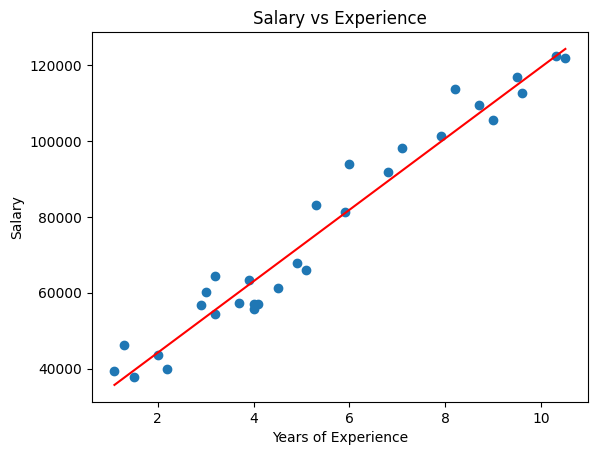

In [22]:
# Visualize the regression line for Task 1
plt.scatter(X, y)

plt.plot(X, model.predict(X), color='red')

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")

plt.show()

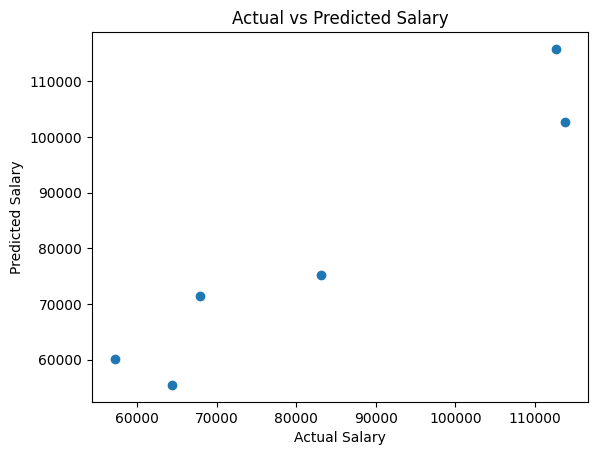

In [23]:
#Plot predicted vs actual values
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

Q) Discuss assumptions of linear regression.

--> Assumptions of Linear Regression

1. Linear Relationship:
   There should be a linear relationship between input and output variables.

2. Independence:
   Data observations should be independent of each other.

3. Homoscedasticity:
   The variance of errors should remain constant.

4. Normal Distribution of Residuals:
   Prediction errors should be approximately normally distributed.

5. No Extreme Outliers:
   Outliers should be minimal because they affect the regression line.

6. No Multicollinearity:
   Input features should not be highly correlated with each other (important in multiple regression).



### Discussion

In this lab I worked on predicting a continuous value, salary, using years of experience as input. I built a simple linear regression model and also compared its behavior with the full dataset setup.

The main point was to understand how a basic ML pipeline works: loading data, cleaning it, choosing features, training the model, and then evaluating how well the predictions match the actual values.

Using all available features together gave the model more information to work with, so the Mean Squared Error and R² score generally improved. This showed that good feature selection matters even in simple tasks.

I also found that a single-feature model is easy to interpret, but it often oversimplifies the real relationship. Multi-feature models usually fit the data better, though they require more care when explaining the results.

Overall, this lab helped me understand what linear regression is trying to do and why each step in the pipeline is useful.


### Conclusion

In this lab I completed a basic machine learning workflow using Linear Regression.

I started by loading the dataset, checked for missing values, selected the input feature, trained the model, and evaluated it using MSE and R² score.

Using multiple features helped improve the prediction compared to using just one feature, which taught me how feature selection affects model performance.

This lab also helped me understand what the coefficients and intercept mean in a regression model, and how to read evaluation metrics in a simple way.

Overall, this was a good starting point for understanding how machine learning models are trained and tested on real data.
